In [3]:
import demes
import demesdraw
import moments
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

<Axes: ylabel='time ago (generations)'>

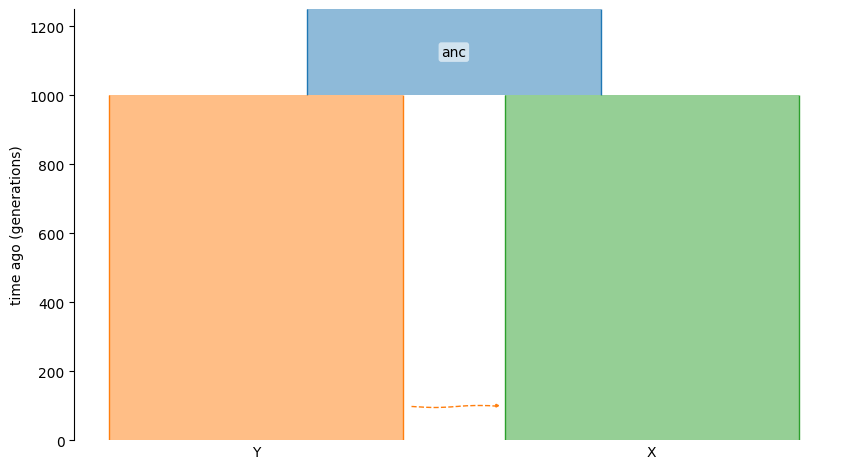

In [51]:
def get_model(p, T, N=1e4, t=1e-5):
    b = demes.Builder()
    b.add_deme("anc", epochs=[{"start_size": N, "end_time": T}])
    b.add_deme("Y", ancestors=["anc"], epochs=[{"start_size": N, "end_time": 0}])
    b.add_deme("X", ancestors=["anc"], epochs=[{"start_size": N, "end_time": 0}])
    b.add_pulse(sources=["Y"], proportions=[p], time=t, dest="X")
    return b.resolve() 


demesdraw.tubes(get_model(0.10, 1e3, N=1e4, t=100))

In [61]:
# approx. 0 introgression

r = np.array([1e-8, 1e-6, 1e-4, 1e-2])
ld = moments.Demes.LD(get_model(1e-10, 1e4), ["X", "Y"], r=r)
print(f"E[T_X] = {ld.H()[0]}")
print(f"E[T_XY] = {ld.H()[1]}")
print(f"E[T_Y] = {ld.H()[2]}")
print(f"Cov_X(T_L, T_R) = {ld.H2(0) - ld.H()[0]**2}")
print(f"Cov_X(T_L, T_R) / E[T_X]^2 = {(ld.H2(0) - ld.H()[0]**2) / ld.H()[0] ** 2}")

E[T_X] = 40000.00000400006
E[T_XY] = 59999.99999799999
E[T_Y] = 40000.00000000006
Cov_X(T_L, T_R) = [1.59957344e+09 1.55839668e+09 4.09302326e+08 4.04798516e+06]
Cov_X(T_L, T_R) / E[T_X]^2 = [0.9997334  0.97399793 0.25581395 0.00252999]


In [69]:
# approx. 0 introgression

r = np.array([1e-8, 1e-6, 1e-4, 1e-2])
ld = moments.Demes.LD(get_model(0.1, 2e4), ["X", "Y"], r=r)
print(f"E[T_X] = {ld.H()[0]}")
print(f"E[T_XY] = {ld.H()[1]}")
print(f"E[T_Y] = {ld.H()[2]}")
print(f"Cov_X(T_L, T_R) = {ld.H2(0) - ld.H()[0]**2}")
print(f"Cov_X(T_L, T_R) / E[T_X]^2 = {(ld.H2(0) - ld.H()[0]**2) / ld.H()[0] ** 2}")

E[T_X] = 47199.99999279982
E[T_XY] = 76000.000002
E[T_Y] = 39999.99999999999
Cov_X(T_L, T_R) = [1.82992491e+09 1.78412677e+09 5.90629653e+08 2.33726344e+08]
Cov_X(T_L, T_R) / E[T_X]^2 = [0.82138974 0.80083254 0.26511314 0.10491164]


In [70]:


r = np.array([1e-8, 1e-6, 1e-4, 1e-2])
ld = moments.Demes.LD(get_model(0.1, 8e4), ["X", "Y"], r=r)
print(f"E[T_X] = {ld.H()[0]}")
print(f"E[T_XY] = {ld.H()[1]}")
print(f"E[T_Y] = {ld.H()[2]}")
print(f"Cov_X(T_L, T_R) = {ld.H2(0) - ld.H()[0]**2}")
print(f"Cov_X(T_L, T_R) / E[T_X]^2 = {(ld.H2(0) - ld.H()[0]**2) / ld.H()[0] ** 2}")

E[T_X] = 68799.9999819994
E[T_XY] = 184000.00000199993
E[T_Y] = 40000.00000000001
Cov_X(T_L, T_R) = [5.28589808e+09 5.23763678e+09 4.04509784e+09 3.68972732e+09]
Cov_X(T_L, T_R) / E[T_X]^2 = [1.11671387 1.10651805 0.85457888 0.77950229]


In [71]:


r = np.array([1e-8, 1e-6, 1e-4, 1e-2])
ld = moments.Demes.LD(get_model(0.1, 8e4, t=500), ["X", "Y"], r=r)
print(f"E[T_X] = {ld.H()[0]}")
print(f"E[T_XY] = {ld.H()[1]}")
print(f"E[T_Y] = {ld.H()[2]}")
print(f"Cov_X(T_L, T_R) = {ld.H2(0) - ld.H()[0]**2}")
print(f"Cov_X(T_L, T_R) / E[T_X]^2 = {(ld.H2(0) - ld.H()[0]**2) / ld.H()[0] ** 2}")

E[T_X] = 67913.3696677125
E[T_XY] = 184100.00000000015
E[T_Y] = 39999.999999999636
Cov_X(T_L, T_R) = [5.22562361e+09 5.17535396e+09 3.77515681e+09 2.24924144e+07]
Cov_X(T_L, T_R) / E[T_X]^2 = [1.13299389 1.12209467 0.81851084 0.00487669]


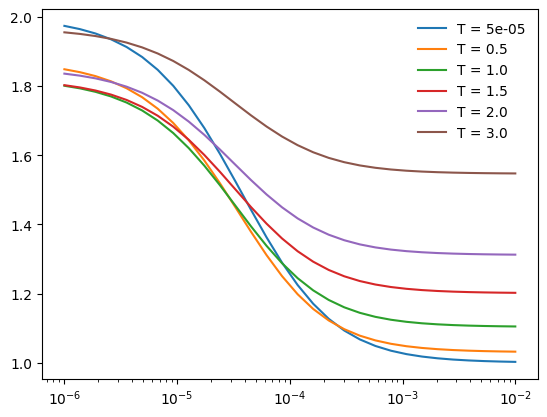

In [86]:
Ts = [1, 1e4, 2e4, 3e4, 4e4, 6e4]
rs = np.logspace(-6, -2, 30)
for T in Ts:
    ld = moments.Demes.LD(get_model(0.1, T), ["X", "Y"], r=rs)
    plt.plot(rs, ld.H2(0) / ld.H()[0] ** 2, label=f"T = {T / 2e4}")
plt.legend(framealpha=0)
plt.xscale("log")

"""
introgression elevates covariance broadly, but depresses the difference between the covariance at tightly and loosely linked sites.
the second effect is explained by the "divergence effect"
"""